In [8]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from projectFinal2 import AUAIRDataset

In [9]:
import json, os, random
from torch.utils.data import DataLoader
from projectFinal2 import yolDöndürme, gorselleriKirp, AUAIRDataset

with open("C:/Users/USER/OneDrive/Belgeler/auair2019annotations/annotations.json", "r") as file:
    tümEtiketler = json.load(file)

etiketHaritası = {}
for e in tümEtiketler['annotations']:
    resimAd = e['image_name'] 
    bbox = e.get('bbox',[])   
    if len(bbox) > 0:
        etiketHaritası[resimAd] = bbox

imageKlasör = "C:/Users/USER/images"     
tümResimler = os.listdir(imageKlasör)

nesneliResimler = [n for n in tümResimler if n in etiketHaritası]

random.seed(3)
random.shuffle(nesneliResimler)

toplamResimSayısı = len(nesneliResimler)
trainDataSınır = int(toplamResimSayısı * 0.7)
validationDataSınır = int(toplamResimSayısı * 0.85)

trainResimleri = nesneliResimler[:trainDataSınır]
validationResimleri = nesneliResimler[trainDataSınır:validationDataSınır]
testResimleri = nesneliResimler[validationDataSınır:]

trainResim = yolDöndürme(trainResimleri)
valResim = yolDöndürme(validationResimleri)
testResim = yolDöndürme(testResimleri)

trainResim = gorselleriKirp(trainResim, "train")
valResim = gorselleriKirp(valResim, "val")
testResim = gorselleriKirp(testResim, "test")

sınıfIndex = {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, 'Background': 8}

testDataset = AUAIRDataset(testResim, sınıfIndex)
testLoad = DataLoader(testDataset, batch_size=32, shuffle=False, num_workers=0)

train görselleri kırpılıyor...
val görselleri kırpılıyor...
test görselleri kırpılıyor...


In [10]:
import torchvision.models as models
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

inFeatures = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.15),
    nn.Linear(inFeatures, 9)
    )

model = model.to(device)

model.load_state_dict(torch.load("EnİyiResnet18Model.pt", map_location=device))
model.eval() 

C:\Users\USER\AppData\Local\Temp\ipykernel_32804\1943194314.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("EnİyiResnet18Model.pt", ma

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
tahminler = []
testEtiketler = []

with torch.no_grad():
    for batchx, batchy in testLoad:
        batchx = batchx.to(device)
        output = model(batchx)
        deger, aitSınıf = torch.max(output, 1)
        
        tahminler.extend(aitSınıf.cpu().numpy())
        testEtiketler.extend(batchy.cpu().numpy())

orijinalİsimler = ['human','car','truck','van','motorbike','bicycle','bus','trailer','Background']

print("\n--- CNN Modelinin Test Seti Sınıflandırma Raporu ---")
print(classification_report(testEtiketler, tahminler, target_names=orijinalİsimler))

print("\n--- CNN Confusion Matrix ---")
print(confusion_matrix(testEtiketler, tahminler))


--- CNN Modelinin Test Seti Sınıflandırma Raporu ---
              precision    recall  f1-score   support

       human       0.88      0.86      0.87       802
         car       0.96      0.97      0.96     15278
       truck       0.70      0.74      0.72      1412
         van       0.64      0.59      0.61      1544
   motorbike       0.68      0.41      0.51        63
     bicycle       0.59      0.77      0.67       157
         bus       0.85      0.68      0.75        97
     trailer       0.53      0.41      0.47       333
  Background       0.99      0.99      0.99      2484

    accuracy                           0.91     22170
   macro avg       0.76      0.71      0.73     22170
weighted avg       0.91      0.91      0.91     22170


--- CNN Confusion Matrix ---
[[  689    40     9     2     3    56     0     0     3]
 [   54 14756    87   327     4     5     3    21    21]
 [    3   115  1051   163     0     1     8    68     3]
 [    2   415   190   911     1     0   

In [12]:
gercekSinifİsimleri = {
    0: 'human',
    1: 'car',
    2: 'truck',
    3: 'van',
    4: 'motorbike',
    5: 'bicycle',
    6: 'bus',
    7: 'trailer',
    8: 'Background'
}

def demo(resimYolu):
    with Image.open(resimYolu) as img:
        img_rgb = img.convert('RGB').resize((224, 224))
        arr = np.array(img_rgb, dtype=np.float32) / 255.0
        tensor_img = torch.from_numpy(arr.transpose((2, 0, 1))).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor_img)
        prob = torch.softmax(output, dim=1)
        max_prob, pred_idx = torch.max(prob, 1)

    tahmin_sinif = gercekSinifİsimleri.get(pred_idx.item(), "Unknown")
    guven = max_prob.item() * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.title(f"Tahmin: {tahmin_sinif} (%{guven:.1f} Güven)", fontsize=12, color='green')
    plt.axis('off')
    plt.show()

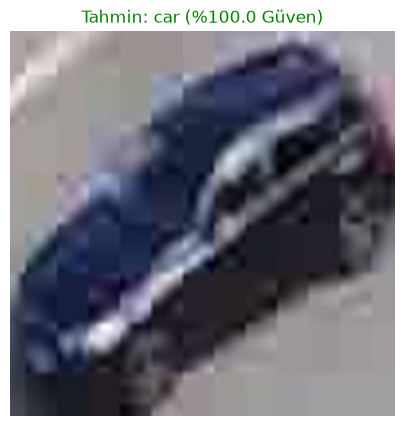

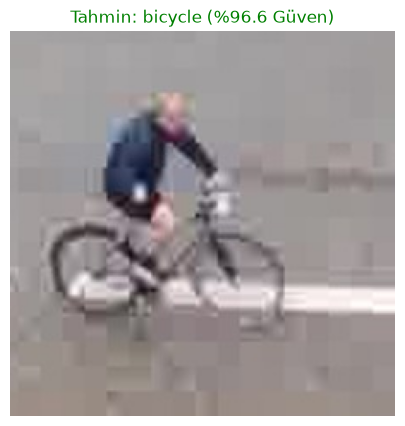

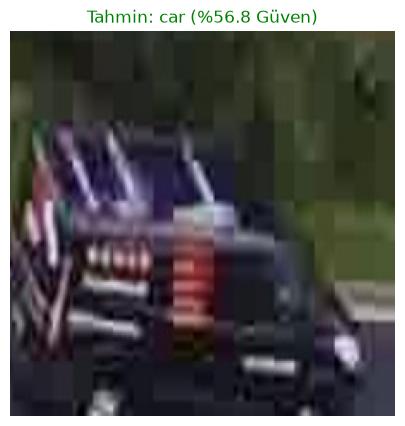

In [13]:
demo("C:/Users/USER/Kırpılmış Resimler/test_0.jpg")
demo("C:/Users/USER/Kırpılmış Resimler/test_18000.jpg")
demo("C:/Users/USER/Kırpılmış Resimler/test_20000.jpg")